In [ ]:
# using GNNs to build network graph from nmap output

# Read the XML `nmap` Output
- Parse `.xml` into nodes, edges, attributes.

Note:
What I have now is not universal, I will need our true `nmap` scans to make this one-size fits all.

In [ ]:
import xml.etree.ElementTree as ET  # ElementTree library is used to parse XML data

xml1 = "../data/nmap_output.xml"
xml2 = "../data/nmap_output_adv.xml"
xml3 = "../data/nmap_stress_test.xml"

tree = ET.parse(xml1)
root = tree.getroot()  # tag that envelopes everything
root.attrib  # length of 6 (scaninfo, host1, host2, host3, host4, runstats)

{'scanner': 'nmap',
 'args': 'nmap -sV -O -oX test_scan.xml 10.0.0.0/30',
 'start': '1733765000',
 'version': '7.94',
 'xmloutputversion': '1.05'}

In [ ]:
# loop over root children and their sub attributes
# find each HOST element
network = {}
for child in root: 
    network_config = {}

    # skip over none host elements
    if child.tag != "host":
        continue

    # pull all IP hosts found (up/down)
    addr = child.findall("address")  # might not be universal (can have ipv4/mac)
    ip_addr = None
    mac_addr = None
    for a in addr:
        # store ipv4 as the main key
        if a.attrib["addrtype"] == "ipv4":
            ip_addr = a.attrib["addr"]

        # if a mac address exists store it
        if a.attrib["addrtype"] == "mac":
            # store other address types
            mac_addr = a.attrib["addr"]
            vendor = a.attrib.get("vendor", None)
            network_config["address"] = {"mac_addr" : mac_addr, "vendor": vendor}

    # use mac as main key if ipv4 not available
    if not ip_addr and mac_addr is not None:
        print("~NO IPV4 VALUE USING MAC INSTEAD")
        ip_addr = mac_addr
        
    # find host's state
    status = child.find("status").attrib["state"]
    if status != "up":  # host is down
        network_config["os"] = None
        network_config["state"] = None
        network_config["hostname"] = None
        network_config["ports"] = None
    else:   # host is up
        # find IP hostname (might contain multiple or none)
        hostname_root = child.find("hostnames")
        if hostname_root is not None:
            hostname_list = []
            for host in hostname_root:
                hostname_list.append(host.attrib) 
        else:
            hostname_list = None

        # find IP OS (either single or multiple)
        os_root = child.find("os")
        if os_root is not None:
            osmatch = os_root.findall("osmatch")
            os_lst = []
            for o in osmatch:
                os_pred = o.attrib
                os_lst.append(os_pred)
            network_config["os"] = os_lst
        else: 
            network_config["os"] = None

        network_config["state"] = status 
        network_config["hostname"] = hostname_list  # store list of hostnames if contains multiple

        # find IP open ports
        # ERROR PORTION (not getting all information)
        port_root = child.find("ports")
        if port_root is not None:
            port_lst = []
            for port in port_root.findall("port"):
                port_data = dict(port.attrib)
                for child in port:
                    if child.tag in ("state", "service"):
                        port_data.update(child.attrib)
                port_lst.append(port_data)
        # if port_root is not None: 
        #     port_lst = []
        #     port_vals = []
        #     port_info = port_root.find("port")
        #     for port in port_root:
        #         print(port.attrib)
        #     # if port.attrib["state"] not in ["closed", "filtered"]:
        #         for val in port:
        #             print(val.attrib)
        #             if val.tag == "state":
        #                 port_vals = port.attrib + val.attrib
        #         port_lst.append(port_vals)
        # else:
        #     port_lst = None

        network_config["ports"] = port_lst

    # add the host into the dictionary
    network[ip_addr] = network_config
    
print(network)


{'10.0.0.1': {'address': {'mac_addr': '00:1A:2B:3C:4D:5E', 'vendor': 'Cisco'}, 'os': [{'name': 'Linux 3.10', 'accuracy': '88'}, {'name': 'Linux 4.x', 'accuracy': '85'}], 'state': 'up', 'hostname': [{'name': 'gateway.local', 'type': 'PTR'}, {'name': 'router.example.com', 'type': 'user'}], 'ports': [{'protocol': 'tcp', 'portid': '80', 'state': 'open', 'reason': 'syn-ack', 'name': 'http', 'product': 'nginx', 'version': '1.18.0'}, {'protocol': 'tcp', 'portid': '443', 'state': 'filtered', 'reason': 'no-response', 'name': 'https'}]}, '10.0.0.2': {'os': None, 'state': 'up', 'hostname': [{'name': 'fileserver.local', 'type': 'PTR'}], 'ports': [{'protocol': 'tcp', 'portid': '21', 'state': 'open', 'reason': 'syn-ack', 'name': 'ftp', 'product': 'vsftpd', 'version': '3.0.3'}, {'protocol': 'tcp', 'portid': '22', 'state': 'closed', 'reason': 'reset'}]}, '10.0.0.3': {'os': [{'name': 'FreeBSD 12', 'accuracy': '90'}], 'state': 'up', 'hostname': [], 'ports': [{'protocol': 'tcp', 'portid': '25', 'state': 

## Turn ElementTree Dictionary into `networkx` graph.

In [25]:
# n=(network["10.0.0.1"]["ports"])
# n

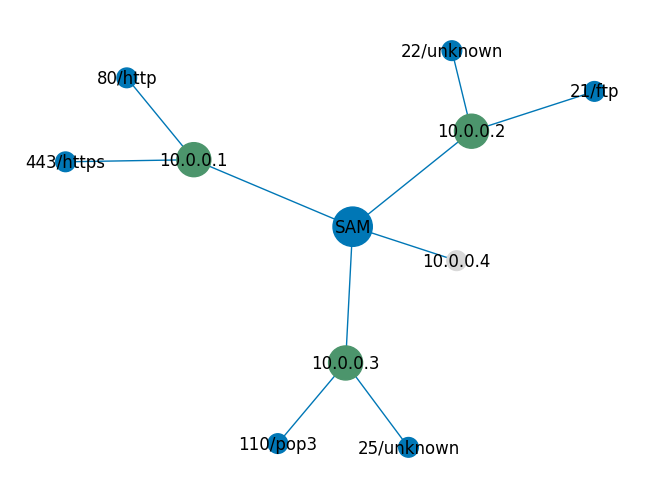

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
SCANNER = "SAM"
# parse the dictionary to get the nodes (scanner -> IP -> Ports)
G.add_node(SCANNER)

for ip in network.keys():
    G.add_node(ip, color="#4c956c" if network[ip]["state"] == "up" else "#d9d9d9")  # adding a node to IP

    # if down connect using dashed lines
    if network[ip]["state"] != "up":
        G.add_edge(SCANNER, ip)
    else:
        G.add_edge(SCANNER, ip)

    # add port edges
    if network[ip]["ports"] is not None:
        for n in network[ip]["ports"]:
            # color code port edges
            
            if int(n["portid"]) in (80, 443):
                color = "#fb8500"
            elif int(n["portid"]) == 22:
                color = "#d9d9d9"
            else:
                color = "#0077b6"

            # print(n)
            service_label = f"{n['portid']}/{n.get('name', 'unknown')}"
            G.add_node(service_label)
            G.add_edge(ip, service_label, color=color)


# display graph
# pull the colors used
node_colors = [G.nodes[n].get("color", "#0077b6") for n in G.nodes()]
edge_colors = nx.get_edge_attributes(G, "color").values()
node_degree = G.degree
nx.draw(
    G,
    pos=nx.spring_layout(G),
    # pos=nx.multipartite_layout(G, subset_key=""), 
    node_color=node_colors,
    edge_color=edge_colors,
    with_labels= True,
    node_size=[v[1] * 200 for v in node_degree]
)

plt.savefig("nmap_out_adv.png")
plt.show()

## Turn `networkx` graph into GNN graph.

In [ ]:
import torch
from torch_geometric.utils.convert import to_networkx, from_networkx

pyg_graph = from_networkx(G)
pyg_graph

## Output GNN graph object.